In [19]:
import os
import glob
import cv2
import seaborn as sns
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

In [3]:
densenet = DenseNet121( weights=None, include_top=False, input_shape=(112,112,1) )

In [4]:
model = Sequential([ 
        densenet,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation='sigmoid')
    ])

In [5]:
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [6]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 3, 3, 1024)     │     7,031,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,032,257 (26.83 MB)

 Trainable params: 6,948,609 (26.51 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [8]:
image_gen = ImageDataGenerator()

In [9]:
test_generator = image_gen.flow_from_directory(
    'dataset/test/',
    target_size=(112, 112),
    batch_size=10,
    color_mode='grayscale',
    class_mode='binary'
)

Found 15000 images belonging to 2 classes.


In [15]:
valid_generator = image_gen.flow_from_directory(
    'dataset/valid/',
    target_size=(112, 112),
    batch_size=10,
    color_mode='grayscale',
    class_mode='binary'
)

Found 15000 images belonging to 2 classes.


In [13]:
model = load_model('./Real_VS_Fake_densenet121.h5')

In [14]:
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [16]:
model.evaluate(valid_generator)

/home/davisp/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 204s 135ms/step - accuracy: 0.9688 - loss: 0.0950


[0.09840695559978485, 0.9667333364486694]

In [17]:
y_pred = model.predict(test_generator)
y_test = test_generator.classes

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 202s 135ms/step


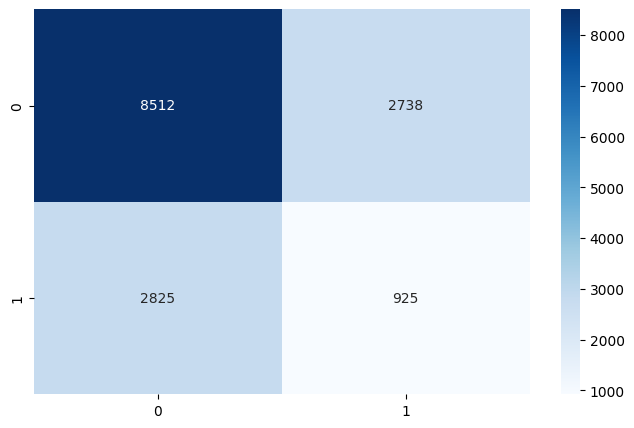

In [29]:
plt.figure(figsize = (8,5))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred.round()), annot = True,fmt="d",cmap = "Blues")
plt.show()

In [31]:
print("ROC-AUC Score:", metrics.roc_auc_score(y_test, y_pred))
print("AP Score:", metrics.average_precision_score(y_test, y_pred))

ROC-AUC Score: 0.5059633422222223
AP Score: 0.25457980297270977


In [33]:
print(metrics.classification_report(y_test, y_pred > 0.5))

              precision    recall  f1-score   support

           0       0.75      0.76      0.75     11250
           1       0.25      0.25      0.25      3750

    accuracy                           0.63     15000
   macro avg       0.50      0.50      0.50     15000
weighted avg       0.63      0.63      0.63     15000



In [34]:
imagem = cv2.imread('./dataset/valid/fake/930_1928-10-04_2006_text2img.jpg')

In [35]:
imagem = cv2.resize(imagem, (112,112))

In [36]:
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

In [37]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

def prever_imagem_unica_keras(caminho_imagem, modelo, tamanho_alvo=(112, 112)):
    img = image.load_img(caminho_imagem, target_size=tamanho_alvo, color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=(0, 3))
    previsao = modelo.predict(img_array)
    return previsao

caminho_imagem = './dataset/valid/fake/930_1928-10-04_2006_text2img.jpg'
previsao = prever_imagem_unica_keras(caminho_imagem, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


In [38]:
print(previsao)

[[0.7701643]]
